### 기본 라이브러리 불러오기

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### User parameter 정의하기

In [2]:
T =  3# 초기 임계값

### toy example(f)을 생성하고, 영상의 크기(h,w)를 자동으로 구하기

In [7]:
f = np.array([[4,5,5,5],
             [11,12,14,9],
             [2,13,13,3],
             [1,2,3,3]])
h,w = f.shape

### 임계값을 적용하여 이진 이미지(g) 만들기

In [8]:
g = np.where(f>T,1,0)

### 초기 임계값을 활용하여, 그룹을 나누기

#### 1번. general

In [11]:
group1 = np.array([])
group2 = np.array([])

for x in range(h):
    for y in range(w):
        if f[x,y] > T:
            group1 = np.append(group1, f[x,y])
        else:
            group2 = np.append(group2, f[x,y])

print(group1)
print(group2)

[ 4.  5.  5.  5. 11. 12. 14.  9. 13. 13.]
[2. 3. 1. 2. 3. 3.]


In [ ]:
#### 2번. easy

In [15]:
group1 = f[f > T]
group2 = f[f <= T]

print(group1)
print(group2)

[ 4  5  5  5 11 12 14  9 13 13]
[2 3 1 2 3 3]


### 각 그룹의 평균(m1,m2)을 계산하고, 새로운 임계값(new_T) 업데이트 하기

In [ ]:
m1 = np.mean(group1)
m2 = np.mean(group2)

new_T = (m1+m2)/2
print(new_T)
T == new_T

# print(m1,m2)

5.716666666666667


 ### matplot 라이브러리를 활용하여 이미지 출력하기

In [ ]:
plt.subplot(1,2,1);plt.imshow(f, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2);plt.imshow(g, cmap="gray"); plt.axis("off")

### new_T를 새로운 임계값으로 설정하고, 4-6번 반복하기

In [ ]:
T = new_T

## 전역적 임계값 처리

In [24]:
T = 125

f = cv2.imread("images/moon.jpg",0)
h,w=f.shape

while True:
    # 팀 나누기
    group1 = f[f > T]
    group2 = f[f <= T]
    # group1 = np.array([])
    # group2 = np.array([])

    # for x in range(h):
    #     for y in range(w):
    #         if f[x,y] > T:
    #             group1 = np.append(group1, f[x,y])
    #         else:
    #             group2 = np.append(group2, f[x,y])

    # 팀 평균 구하기
    m1 = np.mean(group1)
    m2 = np.mean(group2)

    # 평균 업데이트 하기
    new_T = (m1+m2)/2

    print(T,new_T)
    if (T == new_T):
        break
    else:
        T = new_T


g = np.where(f>T,1,0)

125 99.932124600187
99.932124600187 99.77025463510381
99.77025463510381 99.77025463510381


(np.float64(-0.5), np.float64(1199.5), np.float64(674.5), np.float64(-0.5))

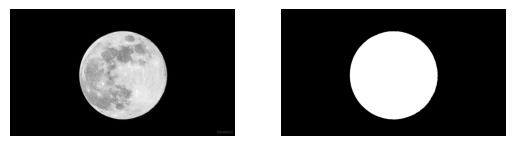

In [25]:
plt.subplot(1,2,1);plt.imshow(f, cmap="gray"); plt.axis("off")
plt.subplot(1,2,2);plt.imshow(g, cmap="gray"); plt.axis("off")